In [1]:
from __future__ import print_function
import os
import sys
# Temporary workaround for Windows OpenMP duplicate runtime initialization in notebooks.
# Must be set before importing torch/torchvision/numpy-linked libraries.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Set up absolute path to the root of the project for importing custom modules.
sys.path.append(os.path.abspath("../.."))

import numpy as np
import torch as torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pickle

from utils.train_val_utils import train_and_evaluate
from utils.test_utils import evaluate_split
from models.ViT.ViT import VisionTransformerProcessor, ViT

torch.manual_seed(42)
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

c:\Users\Tente\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
Using device: cuda


In [2]:
torch.manual_seed(42)
def flip_target(y): 
    return 1 - y

transforms_resize = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = ImageFolder(root="../../butterfly_anomaly_image_resized/final_dataset/train", target_transform=flip_target, transform=transforms_resize)
print("Classes:", train_dataset.classes)
print("Class->idx:", train_dataset.class_to_idx)
print("Total:", len(train_dataset))

val_dataset = ImageFolder(root="../../butterfly_anomaly_image_resized/final_dataset/val", target_transform=flip_target, transform=transforms_resize)
print("Classes:", val_dataset.classes)
print("Class->idx:", val_dataset.class_to_idx)
print("Total:", len(val_dataset))
test_dataset = ImageFolder(root="../../butterfly_anomaly_image_resized/final_dataset/test", target_transform=flip_target, transform=transforms_resize)
print("Classes:", test_dataset.classes)
print("Class->idx:", test_dataset.class_to_idx)
print("Total:", len(test_dataset))

Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


In [ ]:
torch.manual_seed(42)
#Add Augmented Images to Dataset
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Rebuild datasets from the SAME split folders, only changing transforms
aug_train_dataset = ImageFolder(root="../../butterfly_anomaly_image_resized/final_dataset/train", transform=transform_train)

# Optional sanity check: class mapping must match across splits
assert aug_train_dataset.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx

## Models


In [8]:
torch.manual_seed(42)
# Constant parameters
img_size = 224
num_classes = 2
batch_size = 16

# Parameters for model
patch_size = 8
num_patches = (img_size//patch_size)**2 
embed_dim = 64
num_heads = 2
num_layers = 2
mlp_dim = 128
class_weight = 10

# Hyperparameters
epochs = 100
lr = 5e-3
w_decay = 1e-5
dropout = 0.1

vi_processor = VisionTransformerProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device)

model_init = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_init.parameters(), lr = lr, weight_decay=w_decay)
print(model_init)

ViT(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (mlp_head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [ ]:
## INITIAL MODEL 
# ---------------------------
print("="*20)
print("Initial Model Training")
print("="*20)
results_init = train_and_evaluate(model_init, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/vit_base/vit_test_model.pkl', device=device, num_workers=0, embeddings = vi_processor.process_images)

Initial Model Training
  [Epoch 1] Improvement! New best score: 0.961940
Epoch [5/100], Train Loss: 0.6761, Val Loss: 0.5620, Train F1-Macro: 0.1417, Val F1-Macro: 0.4550, Train F1-Per-Class: [0.        0.2833576], Val F1-Per-Class: [0.        0.9099877], Train F2-Macro: 0.2486, Val F2-Macro: 0.4810, Train F2-Per-Class: [0.        0.4971059], Val F2-Per-Class: [0.        0.9619395], No improvement: 4/6
Epoch [5/100], Train Loss: 0.6761, Val Loss: 0.5620, Train F1-Macro: 0.1417, Val F1-Macro: 0.4550, Train F1-Per-Class: [0.        0.2833576], Val F1-Per-Class: [0.        0.9099877] Train F2-Macro: 0.2486, Val F2-Macro: 0.4810, Train F2-Per-Class: [0.        0.4971059], Val F2-Per-Class: [0.        0.9619395]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.961940)


In [ ]:
## CHECK INITIAL MODEL 
# -------------------------------------------
ckpt_file = "../../saved_models/vit_base/vit_test_model.pkl"
hist = model_init.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("Selected epoch:", best["epoch"])
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

7
Selected epoch: 1
F2 over time: [[array([0.       , 0.9619395], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtyp

In [ ]:
# Parameters for model
patch_size = 8
embed_dim = 64
num_patches = (img_size//patch_size)**2
num_heads = 2
num_layers = 2
mlp_dim = 128
class_weight = 15

# Hyperparameters
epochs = 100
lr = 1e-4
w_decay = 1e-5
dropout = 0.1

vi_processor = VisionTransformerProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device)

model_1 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_1.parameters(), lr = lr, weight_decay=w_decay)

print("="*20)
print("Model 1 Training")
print("="*20)
results_init = train_and_evaluate(model_1, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/vit_base/vit_model_1.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 1 Training
Changes Made: learning rate 5e-3 -> 1e-4, class weight 10 -> 15
  [Epoch 1] Improvement! New best score: 0.961940
Epoch [5/100], Train Loss: 0.4033, Val Loss: 1.9680, Train F1-Macro: 0.6004, Val F1-Macro: 0.2432, Train F1-Per-Class: [0.72511846 0.47576007], Val F1-Per-Class: [0.         0.48630136], Train F2-Macro: 0.6574, Val F2-Macro: 0.2099, Train F2-Per-Class: [0.6231487 0.691591 ], Val F2-Per-Class: [0.        0.4198699], No improvement: 4/6
Epoch [5/100], Train Loss: 0.4033, Val Loss: 1.9680, Train F1-Macro: 0.6004, Val F1-Macro: 0.2432, Train F1-Per-Class: [0.72511846 0.47576007], Val F1-Per-Class: [0.         0.48630136] Train F2-Macro: 0.6574, Val F2-Macro: 0.2099, Train F2-Per-Class: [0.6231487 0.691591 ], Val F2-Per-Class: [0.        0.4198699]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.961940)


In [ ]:
## CHECK  MODEL 1
# -------------------------------------------
ckpt_file = "../../saved_models/vit_base/vit_model_1.pkl"
hist = model_1.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F1 (class 0):", float(best["metrics"]["val_f1_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

7
F2 over time: [[array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.        , 0.56160456], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.        , 0.56160456], dtype=float32), array([0.        , 0.52570766], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.        , 0.56160456], dtype=float32), array([0.        , 0.52570766], dtype=float32), array([0.       , 0.4198699], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.        , 0.56160456], dtype=float32), array([0.        , 0.52570766], dtype=float32), array([0.       , 0.4198699], dtype=float32), array([0.02581756, 0.25475752], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.        , 0.56160456], dtype=

In [ ]:
# Parameters for model
patch_size = 8
embed_dim = 64
num_patches = (img_size//patch_size)**2
num_heads = 2
num_layers = 2
mlp_dim = 128
class_weight = 5

# Hyperparameters
epochs = 100
lr = 1e-4
w_decay = 1e-5
dropout = 0.1

#w_decy 1e-5 better than 1e-4
vi_processor = VisionTransformerProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device)

model_2 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_2.parameters(), lr = lr, weight_decay=w_decay)

print("="*20)
print("Model 2 Training")
print("="*20)
#Test Evaluate
results_init = train_and_evaluate(model_2, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/vit_base/vit_model_2.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 2 Training
Changes Made: class weight 15 -> 5
  [Epoch 1] Improvement! New best score: 0.000000
  [Epoch 2] Improvement! New best score: 0.536332
Epoch [5/100], Train Loss: 0.3632, Val Loss: 2.1255, Train F1-Macro: 0.7586, Val F1-Macro: 0.1953, Train F1-Per-Class: [0.8838854 0.6333725], Val F1-Per-Class: [0.00591716 0.3846154 ], Train F2-Macro: 0.8072, Val F2-Macro: 0.1633, Train F2-Per-Class: [0.8341529 0.7802548], Val F2-Per-Class: [0.00897666 0.31760436], No improvement: 3/6
Epoch [5/100], Train Loss: 0.3632, Val Loss: 2.1255, Train F1-Macro: 0.7586, Val F1-Macro: 0.1953, Train F1-Per-Class: [0.8838854 0.6333725], Val F1-Per-Class: [0.00591716 0.3846154 ] Train F2-Macro: 0.8072, Val F2-Macro: 0.1633, Train F2-Per-Class: [0.8341529 0.7802548], Val F2-Per-Class: [0.00897666 0.31760436]

Early stopping at epoch 8. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.536332)


In [ ]:
## CHECK  MODEL 2
# -------------------------------------------
ckpt_file = "../../saved_models/vit_base/vit_model_2.pkl"
hist = model_2.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

8
F2 over time: [[array([0.4972752, 0.       ], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.05794702, 0.1992528 ], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.05794702, 0.1992528 ], dtype=float32), array([0.00897666, 0.31760436], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.05794702, 0.1992528 ], dtype=float32), array([0.00897666, 0.31760436], dtype=float32), array([0.04966887, 0.19613947], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.05794702, 0.1992528 ], dtype=float32), array([0.00897666, 0.31760436], dtype=float32), array([0.04966887, 0.19613947], dtype=fl

In [ ]:
# Parameters for model
img_size = 224
patch_size = 8
embed_dim = 64
num_patches = (img_size//patch_size)**2
num_classes = 2
num_heads = 2
num_layers = 2
mlp_dim = 128
batch_size = 16
class_weight = 5

# Hyperparameters
epochs = 200
lr = 1e-5
w_decay = 1e-5
dropout = 0.1

vi_processor = VisionTransformerProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device)

model_3 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_3.parameters(), lr = lr, weight_decay=w_decay)

print("="*20)
print("Model 3 Training")
print("="*20)
results_init = train_and_evaluate(model_3, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/vit_base/vit_model_3.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 3 Training
Changes Made: lr 1e-4 -> 1e-5
  [Epoch 1] Improvement! New best score: 0.000000
Epoch [5/200], Train Loss: 0.6914, Val Loss: 0.7575, Train F1-Macro: 0.4550, Val F1-Macro: 0.1417, Train F1-Per-Class: [0.9100431 0.       ], Val F1-Per-Class: [0.28349516 0.        ], Train F2-Macro: 0.4810, Val F2-Macro: 0.2486, Train F2-Per-Class: [0.9619643 0.       ], Val F2-Per-Class: [0.4972752 0.       ], No improvement: 4/6
Epoch [5/200], Train Loss: 0.6914, Val Loss: 0.7575, Train F1-Macro: 0.4550, Val F1-Macro: 0.1417, Train F1-Per-Class: [0.9100431 0.       ], Val F1-Per-Class: [0.28349516 0.        ] Train F2-Macro: 0.4810, Val F2-Macro: 0.2486, Train F2-Per-Class: [0.9619643 0.       ], Val F2-Per-Class: [0.4972752 0.       ]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.000000)


In [ ]:
## CHECK  MODEL 3
# -------------------------------------------
ckpt_file = "../../saved_models/vit_base/vit_model_3.pkl"
hist = model_3.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("Selected epoch:", best["epoch"])
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F1 (class 0):", float(best["metrics"]["val_f1_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

7
Selected epoch: 1
F2 over time: [[array([0.4972752, 0.       ], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtype=float32), array([0.4972752, 0.       ], dtyp

In [ ]:
# Parameters for model
img_size = 224
patch_size = 8
embed_dim = 64
num_patches = (img_size//patch_size)**2
num_classes = 2
num_heads = 2
num_layers = 2
mlp_dim = 128
batch_size = 16
class_weight = 5

# Hyperparameters
epochs = 100
lr = 1e-6
w_decay = 1e-5
dropout = 0.1

vi_processor = VisionTransformerProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device)

model_4 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_4.parameters(), lr = lr, weight_decay=w_decay)

print("="*20)
print("Model 4 Training")
print("="*20)
results_init = train_and_evaluate(model_4, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/vit_base/vit_model_4.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 4 Training
Changes Made: lr 1e-4 -> 1e-6
  [Epoch 1] Improvement! New best score: 0.000000
Epoch [5/100], Train Loss: 0.6898, Val Loss: 0.7807, Train F1-Macro: 0.4550, Val F1-Macro: 0.1417, Train F1-Per-Class: [0.9100431 0.       ], Val F1-Per-Class: [0.28349516 0.        ], Train F2-Macro: 0.4810, Val F2-Macro: 0.2486, Train F2-Per-Class: [0.9619643 0.       ], Val F2-Per-Class: [0.4972752 0.       ], No improvement: 4/6
Epoch [5/100], Train Loss: 0.6898, Val Loss: 0.7807, Train F1-Macro: 0.4550, Val F1-Macro: 0.1417, Train F1-Per-Class: [0.9100431 0.       ], Val F1-Per-Class: [0.28349516 0.        ] Train F2-Macro: 0.4810, Val F2-Macro: 0.2486, Train F2-Per-Class: [0.9619643 0.       ], Val F2-Per-Class: [0.4972752 0.       ]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.000000)


In [ ]:
## CHECK  MODEL 4
# -------------------------------------------
ckpt_file = "../../saved_models/vit_base/vit_model_4.pkl"
hist = model_4.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F1 (class 0):", float(best["metrics"]["val_f1_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

7
Selected epoch: 1
Best Train & Val Loss: 0.6953178708617752 and 0.77227883040905
Best val F1 (class 0): 0.283495157957077
Best val F2 (class 1): 0.0


In [ ]:
# Parameters for model
img_size = 224
patch_size = 8
embed_dim = 64
num_patches = (img_size//patch_size)**2
num_classes = 2
num_heads = 2
num_layers = 2
mlp_dim = 128
batch_size = 16
class_weight = 5

# Hyperparameters
epochs = 100
lr = 1e-4
w_decay = 1e-5
dropout = 0.2

vi_processor = VisionTransformerProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device)

model_5 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_5.parameters(), lr = lr, weight_decay=w_decay)

#Test Evaluate
print("="*20)
print("Model 5 Training")
print("="*20)
results_init = train_and_evaluate(model_5, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/vit_base/vit_model_5.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 5 Training
Changes Made: dropout 0.1 -> 0.2
  [Epoch 1] Improvement! New best score: 0.000000
  [Epoch 2] Improvement! New best score: 0.016880
  [Epoch 3] Improvement! New best score: 0.536332
Epoch [5/100], Train Loss: 0.5620, Val Loss: 1.7408, Train F1-Macro: 0.5241, Val F1-Macro: 0.3005, Train F1-Per-Class: [0.62965536 0.4184526 ], Val F1-Per-Class: [0.0077821 0.5933014], Train F2-Macro: 0.5777, Val F2-Macro: 0.2734, Train F2-Per-Class: [0.5161168 0.6392897], Val F2-Per-Class: [0.0105042 0.5363322], No improvement: 2/6
Epoch [5/100], Train Loss: 0.5620, Val Loss: 1.7408, Train F1-Macro: 0.5241, Val F1-Macro: 0.3005, Train F1-Per-Class: [0.62965536 0.4184526 ], Val F1-Per-Class: [0.0077821 0.5933014] Train F2-Macro: 0.5777, Val F2-Macro: 0.2734, Train F2-Per-Class: [0.5161168 0.6392897], Val F2-Per-Class: [0.0105042 0.5363322]

Early stopping at epoch 9. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.536332)


In [ ]:
## CHECK  MODEL 5
# -------------------------------------------
ckpt_file = "../../saved_models/vit_base/vit_model_5.pkl"
hist = model_5.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

9
Selected epoch: 3
Best Train & Val Loss: 0.6374281883776725 and 0.9622166305780411
Best val F2 (class 0): 0.010504201985895634
Best val F2 (class 1): 0.5363321900367737


In [ ]:
# Parameters for model
img_size = 224
patch_size = 8
embed_dim = 64
num_patches = (img_size//patch_size)**2
num_classes = 2
num_heads = 2
num_layers = 2
mlp_dim = 128
batch_size = 16
class_weight = 5

# Hyperparameters
epochs = 100
lr = 1e-4
w_decay = 1e-5
dropout = 0.4

vi_processor = VisionTransformerProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device)

model_6 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_6.parameters(), lr = lr, weight_decay=w_decay)

#Test Evaluate
print("="*20)
print("Model 6 Training")
print("="*20)
results_init = train_and_evaluate(model_6, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/vit_base/vit_model_6.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 6 Training
Changes Made: dropout 0.1 -> 0.4
  [Epoch 1] Improvement! New best score: 0.511034
  [Epoch 4] Improvement! New best score: 0.533756
Epoch [5/100], Train Loss: 0.6033, Val Loss: 1.4367, Train F1-Macro: 0.6112, Val F1-Macro: 0.2783, Train F1-Per-Class: [0.7880319 0.434422 ], Val F1-Per-Class: [0.00724638 0.5493421 ], Train F2-Macro: 0.6465, Val F2-Macro: 0.2485, Train F2-Per-Class: [0.7238204 0.5691388], Val F2-Per-Class: [0.01010101 0.48688048], No improvement: 1/6
Epoch [5/100], Train Loss: 0.6033, Val Loss: 1.4367, Train F1-Macro: 0.6112, Val F1-Macro: 0.2783, Train F1-Per-Class: [0.7880319 0.434422 ], Val F1-Per-Class: [0.00724638 0.5493421 ] Train F2-Macro: 0.6465, Val F2-Macro: 0.2485, Train F2-Per-Class: [0.7238204 0.5691388], Val F2-Per-Class: [0.01010101 0.48688048]
Epoch [10/100], Train Loss: 0.3710, Val Loss: 2.5723, Train F1-Macro: 0.7498, Val F1-Macro: 0.1801, Train F1-Per-Class: [0.87516475 0.6243626 ], Val F1-Per-Class: [0.02240896 0.33776093], Train F2-M

In [ ]:
## CHECK  MODEL 6
# -------------------------------------------
ckpt_file = "../../saved_models/vit_base/vit_model_6.pkl"
hist = model_6.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

10
Selected epoch: 4
Best Train & Val Loss: 0.6495417489393337 and 0.9338773531573159
Best val F2 (class 0): 0.010482179932296276
Best val F2 (class 1): 0.5337564945220947


In [ ]:
# Constant Parameters
img_size = 224
num_classes = 2
batch_size = 16

# Parameters for model
patch_size = 8
embed_dim = 64
num_patches = (img_size//patch_size)**2
num_heads = 4
num_layers = 4
mlp_dim = 128
class_weight = 5

# Hyperparameters
epochs = 100
lr = 1e-4
w_decay = 1e-5
dropout = 0.4

vi_processor = VisionTransformerProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device)

model_7 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_7.parameters(), lr = lr, weight_decay=w_decay)

#Test Evaluate
print("="*20)
print("Model 7 Training")
print("="*20)
results_init = train_and_evaluate(model_7, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/vit_base/vit_model_7.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 7 Training
  [Epoch 1] Improvement! New best score: 0.000000
  [Epoch 3] Improvement! New best score: 0.140984
  [Epoch 4] Improvement! New best score: 0.536332
Epoch [5/100], Train Loss: 0.4247, Val Loss: 2.8142, Train F1-Macro: 0.7680, Val F1-Macro: 0.1650, Train F1-Per-Class: [0.8910233 0.645006 ], Val F1-Per-Class: [0.02710027 0.30291262], Train F2-Macro: 0.8149, Val F2-Macro: 0.1415, Train F2-Per-Class: [0.8447744  0.78500295], Val F2-Per-Class: [0.04251701 0.2404439 ], No improvement: 1/6
Epoch [5/100], Train Loss: 0.4247, Val Loss: 2.8142, Train F1-Macro: 0.7680, Val F1-Macro: 0.1650, Train F1-Per-Class: [0.8910233 0.645006 ], Val F1-Per-Class: [0.02710027 0.30291262] Train F2-Macro: 0.8149, Val F2-Macro: 0.1415, Train F2-Per-Class: [0.8447744  0.78500295], Val F2-Per-Class: [0.04251701 0.2404439 ]
Epoch [10/100], Train Loss: 0.3664, Val Loss: 2.8528, Train F1-Macro: 0.7732, Val F1-Macro: 0.1426, Train F1-Per-Class: [0.8947368  0.65164435], Val F1-Per-Class: [0.02617801 0.

In [ ]:
## CHECK  MODEL 7
# -------------------------------------------
ckpt_file = "../../saved_models/vit_base/vit_model_7.pkl"
hist = model_7.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

10
Selected epoch: 4
Best Train & Val Loss: 0.5393204258100407 and 1.9446060497845923
Best val F2 (class 0): 0.010504201985895634
Best val F2 (class 1): 0.5363321900367737


In [ ]:
## MODEL 8
# -------------------------------------

# Parameters for model
patch_size = 8
embed_dim = 64
num_patches = (img_size//patch_size)**2
num_heads = 4
num_layers = 2
mlp_dim = 128
class_weight = 5

# Hyperparameters
epochs = 100
lr = 1e-4
w_decay = 1e-5
dropout = 0.4

vi_processor = VisionTransformerProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device)

model_8 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_8.parameters(), lr = lr, weight_decay=w_decay)

#Test Evaluate
print("="*20)
print("Model 8 Training")
print("="*20)
results_init = train_and_evaluate(model_8, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/vit_base/vit_model_8.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 8 Training
  [Epoch 1] Improvement! New best score: 0.115817
  [Epoch 3] Improvement! New best score: 0.534065
Epoch [5/100], Train Loss: 0.5528, Val Loss: 1.4823, Train F1-Macro: 0.5853, Val F1-Macro: 0.2598, Train F1-Per-Class: [0.7083697  0.46221864], Val F1-Per-Class: [0.00687285 0.51264757], Train F2-Macro: 0.6411, Val F2-Macro: 0.2284, Train F2-Per-Class: [0.6040892 0.678066 ], Val F2-Per-Class: [0.00980392 0.44705883], No improvement: 2/6
Epoch [5/100], Train Loss: 0.5528, Val Loss: 1.4823, Train F1-Macro: 0.5853, Val F1-Macro: 0.2598, Train F1-Per-Class: [0.7083697  0.46221864], Val F1-Per-Class: [0.00687285 0.51264757] Train F2-Macro: 0.6411, Val F2-Macro: 0.2284, Train F2-Per-Class: [0.6040892 0.678066 ], Val F2-Per-Class: [0.00980392 0.44705883]

Early stopping at epoch 9. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.534065)


In [ ]:
## CHECK  MODEL 8
# -------------------------------------------
ckpt_file = "../../saved_models/vit_base/vit_model_8.pkl"
hist = model_8.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f1_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

16
F2 over time: [[array([0.       , 0.9619395], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.0105042, 0.5363322], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.        , 0.58185965], dtype=float32)], [a

In [ ]:
## MODEL 9
# -------------------------------------
# Parameters for model
patch_size = 4
embed_dim = 64
num_patches = (img_size//patch_size)**2
num_heads = 4
num_layers = 4 
mlp_dim = 128
class_weight = 5

# Hyperparameters
epochs = 100
lr = 1e-4
w_decay = 1e-5
dropout = 0.4

vi_processor = VisionTransformerProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device)

model_9 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_9.parameters(), lr = lr, weight_decay=w_decay)

#Test Evaluate
print("="*20)
print("Model 9 Training")
print("="*20)
results_init = train_and_evaluate(model_9, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/vit_base/vit_model_9.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 9 Training
  [Epoch 1] Improvement! New best score: 0.607264
Epoch [5/100], Train Loss: 0.4549, Val Loss: 3.0465, Train F1-Macro: 0.7876, Val F1-Macro: 0.1327, Train F1-Per-Class: [0.9064879  0.66880614], Val F1-Per-Class: [0.04050633 0.22494887], Train F2-Macro: 0.8283, Val F2-Macro: 0.1187, Train F2-Per-Class: [0.86961055 0.78700906], Val F2-Per-Class: [0.06514658 0.17230576], No improvement: 4/6
Epoch [5/100], Train Loss: 0.4549, Val Loss: 3.0465, Train F1-Macro: 0.7876, Val F1-Macro: 0.1327, Train F1-Per-Class: [0.9064879  0.66880614], Val F1-Per-Class: [0.04050633 0.22494887] Train F2-Macro: 0.8283, Val F2-Macro: 0.1187, Train F2-Per-Class: [0.86961055 0.78700906], Val F2-Per-Class: [0.06514658 0.17230576]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.607264)


In [ ]:
## CHECK  MODEL 9
# -------------------------------------------
ckpt_file = "../../saved_models/vit_base/vit_model_9.pkl"
hist = model_9.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

14
F2 over time: [[array([0.       , 0.9619395], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.        , 0.95772445], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.        , 0.95772445], dtype=float32), array([0.0105042, 0.5363322], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.        , 0.95772445], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.0105042, 0.5363322], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.        , 0.95772445], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.01052632, 0.5389049 ], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.        , 0.95772445], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.01052632, 0.5389049 ], dtype=float32), array([0.      , 0.553961], dtype=flo

In [ ]:
## MODEL 10
# -------------------------------------
# Parameters for model
patch_size = 16
embed_dim = 64
num_patches = (img_size//patch_size)**2
num_heads = 4
num_layers = 4
mlp_dim = 128
class_weight = 5

# Hyperparameters
epochs = 100
lr = 1e-4
w_decay = 1e-5
dropout = 0.4

vi_processor = VisionTransformerProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device)

model_10 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_10.parameters(), lr = lr, weight_decay=w_decay)

#Test Evaluate
print("="*20)
print("Model 10 Training")
print("="*20)
results_init = train_and_evaluate(model_10, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/vit_base/vit_model_10.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 10 Training
  [Epoch 1] Improvement! New best score: 0.000000
  [Epoch 4] Improvement! New best score: 0.023601
  [Epoch 5] Improvement! New best score: 0.536332
Epoch [5/100], Train Loss: 0.5969, Val Loss: 1.6142, Train F1-Macro: 0.5372, Val F1-Macro: 0.3005, Train F1-Per-Class: [0.663707   0.41073513], Val F1-Per-Class: [0.0077821 0.5933014], Train F2-Macro: 0.5849, Val F2-Macro: 0.2734, Train F2-Per-Class: [0.559213 0.610687], Val F2-Per-Class: [0.0105042 0.5363322], No improvement: 0/6
Epoch [5/100], Train Loss: 0.5969, Val Loss: 1.6142, Train F1-Macro: 0.5372, Val F1-Macro: 0.3005, Train F1-Per-Class: [0.663707   0.41073513], Val F1-Per-Class: [0.0077821 0.5933014] Train F2-Macro: 0.5849, Val F2-Macro: 0.2734, Train F2-Per-Class: [0.559213 0.610687], Val F2-Per-Class: [0.0105042 0.5363322]
Epoch [10/100], Train Loss: 0.3897, Val Loss: 2.5966, Train F1-Macro: 0.7187, Val F1-Macro: 0.1905, Train F1-Per-Class: [0.8519371  0.58539206], Val F1-Per-Class: [0.        0.3809524], Tr

In [ ]:
## CHECK  MODEL 10
# -------------------------------------------
ckpt_file = "../../saved_models/vit_base/vit_model_10.pkl"
hist = model_10.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

18
F2 over time: [[array([0.       , 0.9619395], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.        , 0.86712915], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.        , 0.86712915], dtype=float32), array([0.        , 0.59191805], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.        , 0.86712915], dtype=float32), array([0.        , 0.59191805], dtype=float32), array([0.0105042, 0.5363322], dtype=float32)], [array([0.       , 0.9619395], dtype=float32), array([0.       , 0.9619395], dtype=float32), array([0.        , 0.86712915], dtype=float32), array([0.        , 0.59191805], dtype=float32), array([0.0105042, 0.5363322], dtype=float32), array([0.        , 0.56414664], dtype

In [ ]:
#TEST SET
# Constant Parameters
img_size = 224
num_classes = 2
batch_size = 16

# Parameters for model
patch_size = 4
embed_dim = 64
num_patches = (img_size//patch_size)**2
num_heads = 4
num_layers = 4
mlp_dim = 128
class_weight = 5

# Hyperparameters
epochs = 100
lr = 1e-4
w_decay = 1e-5
dropout = 0.4

vi_processor = VisionTransformerProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device)

model_final = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_final.parameters(), lr = lr, weight_decay=w_decay)

hybrid_idx = test_dataset.class_to_idx["1_hybrid"]
class_weights = torch.ones(len(test_dataset.classes), device=device)
class_weights[hybrid_idx] = class_weight

criterion = nn.CrossEntropyLoss(weight=class_weights)

ckpt_file = "../../saved_models/vit_base/vit_model_9.pkl"

history = []
with open(ckpt_file, "rb") as f:
    while True:
        try:
            history.append(pickle.load(f))
        except EOFError:
            break

valid = [
r for r in history
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

model_final.load_state_dict(best["model_state_dict"]) 
optimizer.load_state_dict(best["optimizer_state_dict"])

print("="*20)
print("Model Final Test")
print("="*20)
eval_set = evaluate_split(model_final, test_dataset, batch_size, criterion, device, num_workers=0, embeddings = vi_processor.process_images)
print(eval_set)

Model Final Test
{'loss': 0.5881963138069425, 'f1_macro': 0.4545454680919647, 'f1_per_class': array([0.        , 0.90909094], dtype=float32), 'f2_macro': 0.48076921701431274, 'f2_per_class': array([0.        , 0.96153843], dtype=float32)}


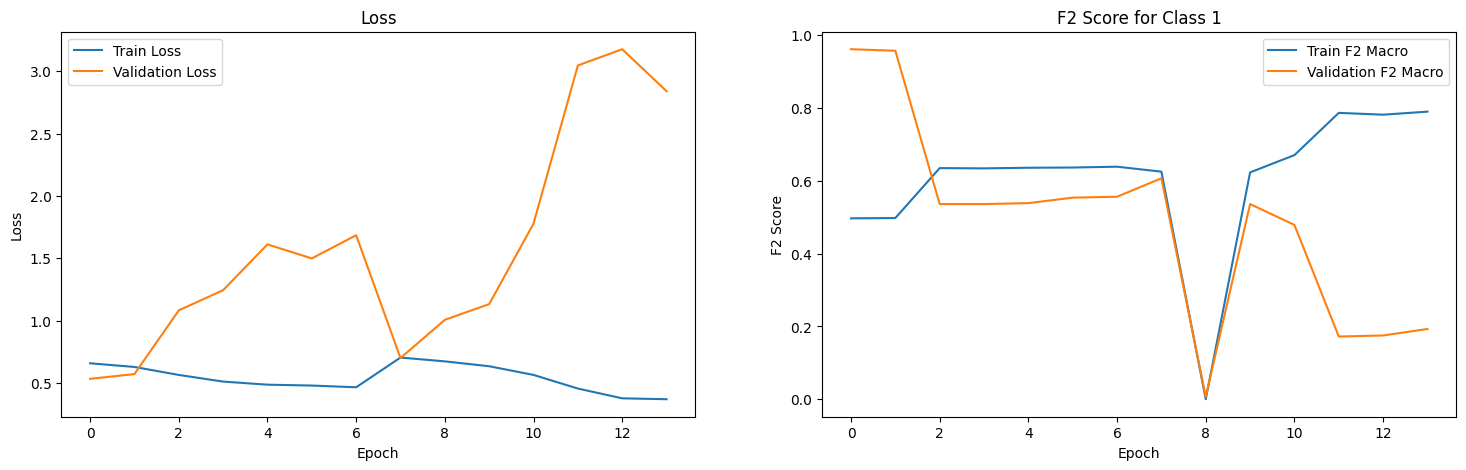

In [ ]:
# Loss and F2 Visualisation
train_loss = [r["metrics"]["train_loss_history"][-1] for r in history ]
val_loss   = [r["metrics"]["val_loss_history"][-1] for r in history]
train_f2   = [r["metrics"]["train_f2_per_class_history"][-1][1] for r in history]
val_f2     = [r["metrics"]["val_f2_per_class_history"][-1][1] for r in history ]
epochs     = [x for x in range(len(history))]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(epochs, train_loss, label="Train Loss")
axes[0].plot(epochs, val_loss, label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs, train_f2, label="Train F2 Macro")
axes[1].plot(epochs, val_f2, label="Validation F2 Macro")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F2 Score")
axes[1].set_title("F2 Score for Class 1")
axes[1].legend()